In [ ]:
!tar -xzf url_svmlight.tar.gz

# **URL Binary Classifier: Malicious vs Benign**


## **Step 1 — Install Dependencies**

In [ ]:
!pip install scikit-learn pandas numpy matplotlib seaborn --quiet

print("All dependencies installed successfully!")


All dependencies installed successfully!


## **Step 2 — Load the UCSD URL Dataset**

In [ ]:
from sklearn.datasets import load_svmlight_file
import numpy as np
import pandas as pd

                                    # Load the SVM-light file
print("Loading dataset...")
X, y = load_svmlight_file("url_svmlight/Day0.svm")              # X gets the URL features, y gets the labels

                                                      # Labels: +1 = Malicious, -1 = Benign
labels = np.where(y == 1, "Malicious", "Benign")   # Converts numbers (1 and -1) into readable text

print(f"Total Malicious : {np.sum(labels == 'Malicious')}")
print(f"Total Benign    : {np.sum(labels == 'Benign')}")
print(f"Total samples   : {len(labels)}")

Loading dataset...
Total Malicious : 5963
Total Benign    : 10037
Total samples   : 16000


## **Step 3 — Sample a Balanced Subset (500 Malicious + 500 Benign)**

In [ ]:
np.random.seed(42)                  # Locks the randomness so the results are exactly the same every time it runs
                                            # Finds the row numbers of all the bad & safe URLs
malicious_indices = np.where(y == 1)[0]
benign_indices    = np.where(y != 1)[0]

                                                                               # Sample 500 of each
sampled_malicious = np.random.choice(malicious_indices, 500, replace=False)
sampled_benign    = np.random.choice(benign_indices,    500, replace=False)

all_sampled_idx = np.concatenate([sampled_malicious, sampled_benign])                     # Combines them into a single list of 1000 URLs
np.random.shuffle(all_sampled_idx)                                                # Shuffles the list so the model doesn't just learn them in a block

print(f"Sampled dataset size: {len(all_sampled_idx)} (500 Malicious + 500 Benign)")

Sampled dataset size: 1000 (500 Malicious + 500 Benign)


## **Step 4 — URL Feature Tokenisation**


In [ ]:
import re                                       # Regular expressions library for text cleaning

def preprocess_url_features(feature_indices):
    """
    Converts active feature indices into a cleaned text string.
    Applies NLP_1 style preprocessing on the tokenised indices:
    - Convert active feature indices to string tokens (tokenisation)
    - Drop any empty tokens (cleaning)
    - Join tokens with spaces, ready for vectorisation
    Note: the UCSD dataset provides pre-extracted numeric feature indices
    rather than raw URL text, so English stop-word removal and punctuation
    regex are not meaningful here and have been omitted.
    """
                                                       # Convert indices to string tokens
    tokens = [str(idx) for idx in feature_indices]         # Turns numerical features (like 14) into text ("14")

    tokens = [t for t in tokens if t]              # Cleans up any blank tokens

    return " ".join(tokens)             # Glues the tokens back together with spaces


url_texts = []               # Empty list to hold the cleaned URL data and labels
url_labels = []

for idx in all_sampled_idx:                                  # Loops through the 1000 sampled URLs
    active_features = X[idx].indices.tolist()                          # Gets the active features for this specific URL
    processed_text  = preprocess_url_features(active_features)
    label           = "Malicious" if y[idx] == 1 else "Benign"        # Assigns the correct text label
    url_texts.append(processed_text)                            # Saves the cleaned text
    url_labels.append(label)

df = pd.DataFrame({'url_features': url_texts, 'label': url_labels})           # Organizes it all into a neat table

print("Sample preprocessed URLs:")
print(df.head(3))
print(f"\nLabel distribution:")
print(df['label'].value_counts())


Sample preprocessed URLs:
                                        url_features      label
0  1 3 4 5 10 16 17 18 20 21 22 23 24 36 43 44 47...  Malicious
1  1 3 4 5 10 16 17 18 20 21 35 43 46 47 50 61 63...  Malicious
2  3 4 5 10 20 21 23 27 32 35 40 43 61 63 65 67 7...     Benign

Label distribution:
label
Malicious    500
Benign       500
Name: count, dtype: int64


*from week 7 lecture material*

## **Step 5 — TF-IDF Embedding**



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import pandas as pd

                                                       # Train/test split (80/20) — stratified to preserve 50/50 class balance
X_train, X_test, y_train, y_test = train_test_split(
    df['url_features'], df['label'],
    test_size=0.2,                                # Sets 20% of data aside for testing
    random_state=42,                          # Keeps the split consistent every time
    stratify=df['label']                   # Ensures train and test sets both stay exactly 50/50 balanced
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")


                               # ngram_range=(1,2) captures individual features and feature pairs
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),                        # Looks at individual features AND pairs of features
    max_features=2000            # Keeps only the top 2000 most important patterns to stay lightweight
)


X_train_tfidf = vectorizer.fit_transform(X_train)          # Learns vocabulary from train data AND converts it to vectors
X_test_tfidf  = vectorizer.transform(X_test)          # Converts test data using the vocabulary already learned above

print(f"\nTF-IDF embedding shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF embedding shape (test) : {X_test_tfidf.shape}")
print("\nEach URL is now represented as a vector of", X_train_tfidf.shape[1], "dimensions")

Training samples : 800
Test samples     : 200

TF-IDF embedding shape (train): (800, 2000)
TF-IDF embedding shape (test) : (200, 2000)

Each URL is now represented as a vector of 2000 dimensions


*from week 8 lecture material*

## **Step 6 — Logistic Regression Classifier**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

                            # Train Logistic Regression
clf = LogisticRegression(
    C=1.0,                                  # Standard regularization (prevents over-memorizing)
    solver='liblinear',               # Fast algorithm for small/binary datasets
    max_iter=1000,                         # Gives the model plenty of time to find the best fit
    random_state=42
)

clf.fit(X_train_tfidf, y_train)                     # Actual "learning" step: studies the training vectors

                                  # Predict
y_pred = clf.predict(X_test_tfidf)                  # Tests the model by asking it to guess labels for unseen data

                                 # Evaluation metrics
print("=" * 50)
print("       MODEL EVALUATION RESULTS")
print("=" * 50)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")                            # Overall percentage of correct guesses
print(f"F1 Score  : {f1_score(y_test, y_pred, pos_label='Malicious'):.4f}")                    #  Balance of precision and recall
print(f"Precision : {precision_score(y_test, y_pred, pos_label='Malicious'):.4f}")     # When it guesses malicious, how often is it right?
print(f"Recall    : {recall_score(y_test, y_pred, pos_label='Malicious'):.4f}")            # Out of all actual malicious URLs, how many did it catch?
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Benign", "Malicious"]))        # Prints a detailed scoring

       MODEL EVALUATION RESULTS
Accuracy  : 0.9650
F1 Score  : 0.9645
Precision : 0.9794
Recall    : 0.9500

Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      0.98      0.97       100
   Malicious       0.98      0.95      0.96       100

    accuracy                           0.96       200
   macro avg       0.97      0.96      0.96       200
weighted avg       0.97      0.96      0.96       200



*from week 8 lecture material*

## **Step 7 — Confusion Matrix Visualisation**

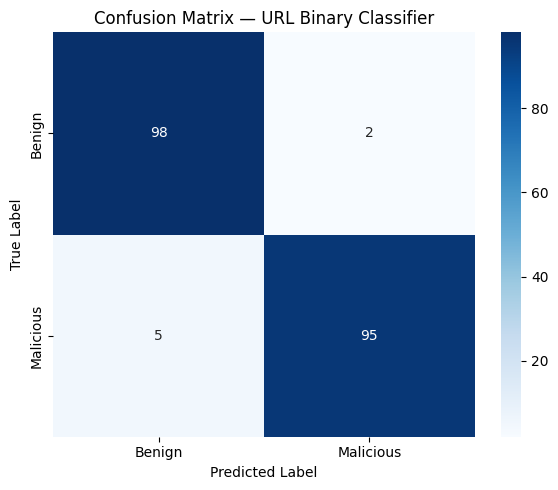

Confusion matrix saved as confusion_matrix.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


cm = confusion_matrix(y_test, y_pred, labels=["Benign", "Malicious"])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Benign", "Malicious"],
    yticklabels=["Benign", "Malicious"]
)
plt.title("Confusion Matrix — URL Binary Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Confusion matrix saved as confusion_matrix.png")

*from week 8 lecture material*

AI assistance: *When developing the classification pipeline, AI tools such as Gemini were used to help structure and syntax the Python code, as some techniques could not be found in the lecture materials.*